In [2]:
from datetime import datetime

from bluemath_tk.wrappers.schism.schism_wrapper import SchismOnlyWindModelWrapper

In [ ]:
fixed_parameters = {
    "tini": datetime(2020, 7, 11, 0, 0),
    "tend": datetime(2020, 7, 11, 17, 0),
    "dt": 300,  # dt = 120 -> timestem (s) # nspool = 360; by default. It saves a data each nspool * dt = 30*120 = 3600 s = 1 h,
    "utc_start": 8,
    "nspool": 12,
    "ihfskip": 518400,
    "nws": 1, # wind form .th
    "ics": 2,  # Coordinate option = 1: Cartesian; 2: lon/lat
    "output_wind_velocity": 1,
}

In [13]:
metamodel_parameters = {
    "wind_magnitude": [30, 30, 30, 30],  # Wind magnitudes (m/s) for each case
    "wind_direction": [0, 90, 180, 270],  # Wind directions (degrees) for each case
}

In [14]:
schism_wrapper = SchismOnlyWindModelWrapper(
    templates_dir="templates",
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
    output_dir="JAVI_TEST",
)

2025-06-05 13:58:55,167 - SchismOnlyWindModelWrapper - WARNING - Parameter wind_magnitude is not in the default_parameters
2025-06-05 13:58:55,168 - SchismOnlyWindModelWrapper - WARNING - Parameter wind_direction is not in the default_parameters


In [15]:
schism_wrapper.build_cases(mode="one_by_one")

In [ ]:
import numpy as np
import os


from datetime import datetime, timedelta

In [ ]:
from utils.wrapper import SchismOnlyWindModelWrapper

In [ ]:
# INPUTS
# ----
# paths
p_templates = "/home/grupos/geocean/ortizanguloj/Github-GeoOcean/BlueMath/methods/dynamical_downscaling/SchismExample/templates"
p_output = "/home/grupos/geocean/ortizanguloj/Github-GeoOcean/BlueMath/methods/dynamical_downscaling/SchismExample/CASES/"

# simulation time

tini = datetime(2020, 7, 11, 0, 0)
tend = datetime(2020, 7, 11, 17, 0)
dt = 300  # dt = 120 -> timestem (s) # nspool = 360; by default. It saves a data each nspool * dt = 30*120 = 3600 s = 1 h

# ----


days_calc = (tend - tini).total_seconds() / 86400
print(f"Total days of simulation: {days_calc} days")


# Start time
start_year = tini.year
start_month = tini.month
start_day = tini.day
start_hour = tini.hour
utc_start = 8  # Time zone
rnday = days_calc  # Total simulation time (day)


In [ ]:
# # Mesh
# nodes = 51366 # Total number of elements (from hgrid.gr3) -> Will be used to generate the tvd.prop file

# # !-----------------------------------------------------------------------
# # ! Transport method.
# # ! If itr_met=1, upwind method is used. If itr_met>=2, TVD or WENO method is used
# # ! on an element/prism if the total depth (at all nodes of the elem.)>=h_tvd and the flag in
# # ! tvd.prop = 1 for the elem. (tvd.prop is required in this case);
# # ! otherwise upwind is used for efficiency.
# # ! itr_met=3 (horizontal TVD) or 4 (horizontal WENO): implicit TVD in the vertical dimension.
# # ! Also if itr_met==3 and h_tvd>=1.e5, some parts of the code are bypassed for efficiency
# # ! Controls for WENO are not yet in place
# # !-----------------------------------------------------------------------
# #   itr_met = 1


# tvd_filename = "tvd.prop"

# # Ruta completa del archivo
# filepath = os.path.join(p_templates, tvd_filename)

# # Escribir el archivo
# with open(filepath, "w") as f:
#     for i in range(1, nodes + 1):
#         f.write(f"{i} 1\n")

# print(f"Archivo guardado en: {filepath}")

In [ ]:
# INPUT PARAMETERS
ics = 2  # Coordinate option = 1: Cartesian; 2: lon/lat

# If nws=0, no atmos. forcing is applied.
# If nws=1, atmos. variables are read in from wind.th
# If nws=2, atmos. variables are read in from sflux_ files.
# If nws=4, ascii format is used for wind and atmos. pressure at each node (see source code): wind.th (time, uwind, vwind, pressure)
# If nws>0, 'iwindoff' can be used to scale wind speed (with windfactor.gr3).
nws = 1


# As wind is constant in this case (nws=1), we need to generate wind.th (time, uwind & vwind)
#  .th now can have its own time step, but MUST start at t=0!
# In the case of wind.th (with nws=1 or 4), the time step specified inside must also match wtiminc in param.nml


# OUTPUT PARAMETERS
nspool = (
    12  # Output step spool. It saves a data each nspool * dt = 30*120 = 3600 s = 1 h
)
ihfskip = 518400  # Stack spool. Number of times that it save the Time step (dt) in each file:​ 43200 * 120 s = 5184000 s/file = 60 days/file (schout). Use 22320 for 31 days​.
# Use 22320 for 31 days​; 5040 for 7 days; 21600 for 30 days; 43200 for 60 days;

# Wind
output_wind_velocity = 1

In [ ]:
# FIXED PARAMETERS
# List with the names of the variables to be included in the fixed_parameters dictionary
var_names = [
    "tini",
    "tend",
    "dt",
    "start_year",
    "start_month",
    "start_day",
    "start_hour",
    "utc_start",
    "rnday",
    "nspool",
    "ihfskip",
    "nws",
    "ics",
    "output_wind_velocity",
]

# Creación del diccionario
fixed_parameters_only_wind = {var_name: globals()[var_name] for var_name in var_names}
fixed_parameters_only_wind  # check it out!

{'tini': datetime.datetime(2020, 7, 11, 0, 0),
 'tend': datetime.datetime(2020, 7, 11, 17, 0),
 'dt': 300,
 'start_year': 2020,
 'start_month': 7,
 'start_day': 11,
 'start_hour': 0,
 'utc_start': 8,
 'rnday': 0.7083333333333334,
 'nspool': 12,
 'ihfskip': 518400,
 'nws': 1,
 'ics': 2,
 'output_wind_velocity': 1}

In [ ]:
# METAMODEL PARAMETERS

n_cases = 4  # Number of cases to be generated. In this case, 4 cases with different wind directions

wind_magnitud = [30, 30, 30, 30]  # Wind magnitudes (m/s) for each case
wind_directions = [0, 90, 180, 270]  # Wind directions (degrees) for each case

total_seconds = rnday * 24 * 3600  # Define times in seconds for .th file
times = np.arange(0, total_seconds + dt, dt)  # Generate time vector


In [10]:
def times_wind_list(n_cases, vector):
    # Crear una lista con el vector repetido n_cases veces
    return {"Time": [np.array(vector) for _ in range(n_cases)]}

In [ ]:
times_wind = times_wind_list(n_cases, times)
print(times_wind)
# times_wind["Time"][0] # first array of the list


{'Time': [array([    0.,   300.,   600.,   900.,  1200.,  1500.,  1800.,  2100.,
        2400.,  2700.,  3000.,  3300.,  3600.,  3900.,  4200.,  4500.,
        4800.,  5100.,  5400.,  5700.,  6000.,  6300.,  6600.,  6900.,
        7200.,  7500.,  7800.,  8100.,  8400.,  8700.,  9000.,  9300.,
        9600.,  9900., 10200., 10500., 10800., 11100., 11400., 11700.,
       12000., 12300., 12600., 12900., 13200., 13500., 13800., 14100.,
       14400., 14700., 15000., 15300., 15600., 15900., 16200., 16500.,
       16800., 17100., 17400., 17700., 18000., 18300., 18600., 18900.,
       19200., 19500., 19800., 20100., 20400., 20700., 21000., 21300.,
       21600., 21900., 22200., 22500., 22800., 23100., 23400., 23700.,
       24000., 24300., 24600., 24900., 25200., 25500., 25800., 26100.,
       26400., 26700., 27000., 27300., 27600., 27900., 28200., 28500.,
       28800., 29100., 29400., 29700., 30000., 30300., 30600., 30900.,
       31200., 31500., 31800., 32100., 32400., 32700., 33000., 3330

In [12]:
def generate_dict(n_cases, vector):
    return {f"Times": np.array(vector) for i in range(n_cases)}

In [ ]:
# Inicialización de matrices u y v
u = np.zeros((n_cases, len(times)))
v = np.zeros((n_cases, len(times)))

# Cálculo de u y v para cada caso
for i in range(n_cases):
    # Convertir dirección a radianes
    dir_rad = np.deg2rad(wind_directions[i])

    # Cálculo de u y v
    u[i, :] = -wind_magnitud[i] * np.cos(dir_rad)
    v[i, :] = -wind_magnitud[i] * np.sin(dir_rad)

# Mostrar los primeros 5 valores de u y v para el primer caso
print("Valores constantes de u para cada caso:", u[0:n_cases, 0])
print("Valores constantes de v para cada caso:", v[0:n_cases, 0])


Valores constantes de u para cada caso: [-3.0000000e+01 -1.8369702e-15  3.0000000e+01  5.5109106e-15]
Valores constantes de v para cada caso: [-0.0000000e+00 -3.0000000e+01 -3.6739404e-15  3.0000000e+01]


In [14]:
def matrix_to_dict(matrix, name):
    # Crear el diccionario con cada fila de `matrix` como un array individual
    return {name: [matrix[i, :] for i in range(matrix.shape[0])]}

In [15]:
u_wind = matrix_to_dict(u, "u_wind")
print(u_wind)


{'u_wind': [array([-30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -30., -30., -30., -30., -30., -30.,
       -30., -30., -30., -30., -30., -3

In [16]:
v_wind = matrix_to_dict(v, "v_wind")
print(v_wind)


{'v_wind': [array([-0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0., -0.,
       -0., -0., -0., -0., -0., -0., -0., -0., -0., 

In [ ]:
# merge metamodel diccionaries

metamodel_parameters_only_wind = (
    times_wind | u_wind | v_wind
)  # input for SchismJaredModelWrapper function: inputs that does change between cases
metamodel_parameters_only_wind

{'Time': [array([    0.,   300.,   600.,   900.,  1200.,  1500.,  1800.,  2100.,
          2400.,  2700.,  3000.,  3300.,  3600.,  3900.,  4200.,  4500.,
          4800.,  5100.,  5400.,  5700.,  6000.,  6300.,  6600.,  6900.,
          7200.,  7500.,  7800.,  8100.,  8400.,  8700.,  9000.,  9300.,
          9600.,  9900., 10200., 10500., 10800., 11100., 11400., 11700.,
         12000., 12300., 12600., 12900., 13200., 13500., 13800., 14100.,
         14400., 14700., 15000., 15300., 15600., 15900., 16200., 16500.,
         16800., 17100., 17400., 17700., 18000., 18300., 18600., 18900.,
         19200., 19500., 19800., 20100., 20400., 20700., 21000., 21300.,
         21600., 21900., 22200., 22500., 22800., 23100., 23400., 23700.,
         24000., 24300., 24600., 24900., 25200., 25500., 25800., 26100.,
         26400., 26700., 27000., 27300., 27600., 27900., 28200., 28500.,
         28800., 29100., 29400., 29700., 30000., 30300., 30600., 30900.,
         31200., 31500., 31800., 32100., 32

In [ ]:
schism_wrapper = SchismJaredModelWrapper(
    templates_dir=p_templates,
    metamodel_parameters=metamodel_parameters_only_wind,
    fixed_parameters=fixed_parameters_only_wind,
    output_dir=p_output,
)

2025-05-30 14:20:46,849 - SchismJaredModelWrapper - WARNING - Parameter Time is not in the default_parameters
2025-05-30 14:20:46,850 - SchismJaredModelWrapper - WARNING - Parameter u_wind is not in the default_parameters
2025-05-30 14:20:46,850 - SchismJaredModelWrapper - WARNING - Parameter v_wind is not in the default_parameters


In [19]:
schism_wrapper.build_cases(mode="one_by_one")

In [22]:
schism_wrapper.run_cases_bulk(launcher="launchSchism.sh")

overwriting variable ['PATH']
At line 219 of file /software/geocean/schism/schism_github_schism-dev/src/Hydro/schism_init.F90 (unit = 11)
Fortran runtime error: Cannot open file './/outputs/fatal.error': No such file or directory

Error termination. Backtrace:
#0  0x7f8c54335775 in already_open
	at ../../../libgfortran/io/open.c:719
#1  0x5610faf4726e in ???
#2  0x5610faf23179 in ???
#3  0x5610faf23233 in ???
#4  0x5610faf23060 in ???
#5  0x7f8c538a57e4 in ???
#6  0x5610faf23090 in ???
/software/geocean/bin/launchSchism.sh: línea 15: cd: outputs/: No such file or directory
At line 110 of file combine_output11.f90 (unit = 10)
Fortran runtime error: Cannot open file 'local_to_global_0000': No such file or directory

Error termination. Backtrace:
#0  0x7f9b2a940775 in already_open
	at ../../../libgfortran/io/open.c:719
#1  0x56177475e3c6 in ???
#2  0x56177476a2bf in ???
#3  0x56177475948e in ???
#4  0x7f9b2a0d07e4 in ???
#5  0x5617747594c0 in ???
2025-05-29 17:14:58,392 - SchismJaredModel

Begin:    1, End:    1, dry flag:    0
 combine all variables


In [ ]:
def schism_load(schfile):
    """
    Load schism output file and parse the element/node values to create a (matplotlib) trimesh object for plotting

    Returns xarray dataset and trimesh object
    We should modify this to load multiple files ... probably need assistance from DASK
    """
    schout = xr.open_dataset(schfile)
    # get elements
    # For some reason, the SCHISM elements variable ("face_nodes") uses 1-based indexing,
    # and has a fourth column of NaNs (maybe for 3D meshes?). Also the indices are stored as floats
    elems = np.int32(schout.SCHISM_hgrid_face_nodes[:, :-1] - 1)
    # get lat/lon coordinates of nodes - weird it appears x,y are switched
    lons = schout.SCHISM_hgrid_node_y.values
    lats = schout.SCHISM_hgrid_node_x.values
    # create trimesh object
    meshtri = Triangulation(lats, lons, triangles=elems)
    return schout, meshtri

In [21]:
import xarray as xr
import numpy as np
from matplotlib.tri import Triangulation


In [ ]:
# load file
name_case_1 = "0000"
schfile_1 = "/home/grupos/geocean/ortizanguloj/Github-GeoOcean/BlueMath/methods/dynamical_downscaling/SchismExample/CASES/0000/outputs/schout_1.nc"
schout_1, meshtri_1 = schism_load(schfile_1)

In [ ]:
# assign to lons and lats
lons = schout_1.SCHISM_hgrid_node_x.values
lats = schout_1.SCHISM_hgrid_node_y.values

In [47]:
schout_1

<xarray.Dataset> Size: 36MB
Dimensions:                  (time: 17, one: 1, nSCHISM_hgrid_face: 51366,
                              nMaxSCHISM_hgrid_face_nodes: 4,
                              nSCHISM_hgrid_edge: 78674, two: 2,
                              nSCHISM_hgrid_node: 27184, sigma: 2,
                              nSCHISM_vgrid_layers: 2)
Coordinates:
  * time                     (time) datetime64[ns] 136B 2020-07-11T09:00:00 ....
  * sigma                    (sigma) float32 8B -1.0 0.0
Dimensions without coordinates: one, nSCHISM_hgrid_face,
                                nMaxSCHISM_hgrid_face_nodes,
                                nSCHISM_hgrid_edge, two, nSCHISM_hgrid_node,
                                nSCHISM_vgrid_layers
Data variables: (12/29)
    SCHISM_hgrid             (one) int32 4B ...
    SCHISM_hgrid_face_nodes  (nSCHISM_hgrid_face, nMaxSCHISM_hgrid_face_nodes) float64 2MB ...
    SCHISM_hgrid_edge_nodes  (nSCHISM_hgrid_edge, two) int32 629kB ...
    SCHISM_hgrid_node_x      (nSCHISM_hgrid_node) float64 217kB -3.517 ... -3...
    SCHISM_hgrid_node_y      (nSCHISM_hgrid_node) float64 217kB 43.42 ... 43.43
    node_bottom_index        (nSCHISM_hgrid_node) int32 109kB ...
    ...                       ...
    wetdry_side              (time, nSCHISM_hgrid_edge) float32 5MB ...
    zcor                     (time, nSCHISM_hgrid_node, nSCHISM_vgrid_layers) float32 4MB ...
    elev                     (time, nSCHISM_hgrid_node) float32 2MB ...
    wind_speed               (time, nSCHISM_hgrid_node, two) float32 4MB ...
    dahv                     (time, nSCHISM_hgrid_node, two) float32 4MB ...
    hvel                     (time, nSCHISM_hgrid_node, nSCHISM_vgrid_layers, two) float32 7MB ...
Attributes:
    Conventions:   CF-1.0, UGRID-1.0
    title:         SCHISM Model output
    institution:   SCHISM Model output
    source:        SCHISM model output version v10
    references:    http://ccrm.vims.edu/schismweb/
    history:       created by combine_output11
    comment:       SCHISM Model output
    type:          SCHISM Model output
    VisIT_plugin:  https://schism.water.ca.gov/library/-/document_library/vie...

In [48]:
# # define image path
# path_image = './Google_Earth/VanKIRAP.png'

# # define corners
# x_left, x_rigth = 163.1, 172.1
# y_low, y_upper = -21.57, -12.6

# # load vanuatu background image
# im = plt.imread(path_image)

In [ ]:
# Define land
depth_mod = schout_1.depth.values
depth_mod[depth_mod > 0] = 0

In [ ]:
# Define the time of interest (according to the loaded schout)
date_schism = "2020-07-12T01:00:00.000000000"

In [ ]:
elev = schout_1.elev.sel(time=date_schism)  # v component


In [ ]:
# SCHISM current calculation
u = schout_1.dahv.sel(time=date_schism, two=0)  # u component
v = schout_1.dahv.sel(time=date_schism, two=1)  # v component

m = np.sqrt(u**2 + v**2)  # get current magnitude from u & v components
m  # check it out

<xarray.DataArray 'dahv' (nSCHISM_hgrid_node: 27184)> Size: 109kB
array([0.        , 0.        , 0.        , ..., 0.05291109, 0.04305045,
       0.03426308], shape=(27184,), dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2020-07-12T01:00:00
Dimensions without coordinates: nSCHISM_hgrid_node

/tmp/ipykernel_2257219/3264349832.py:16: UserWarning: linewidths is ignored by contourf
  ax.tricontourf(meshtri_1, depth_mod, cmap='summer', levels=0, linewidths=0.5)


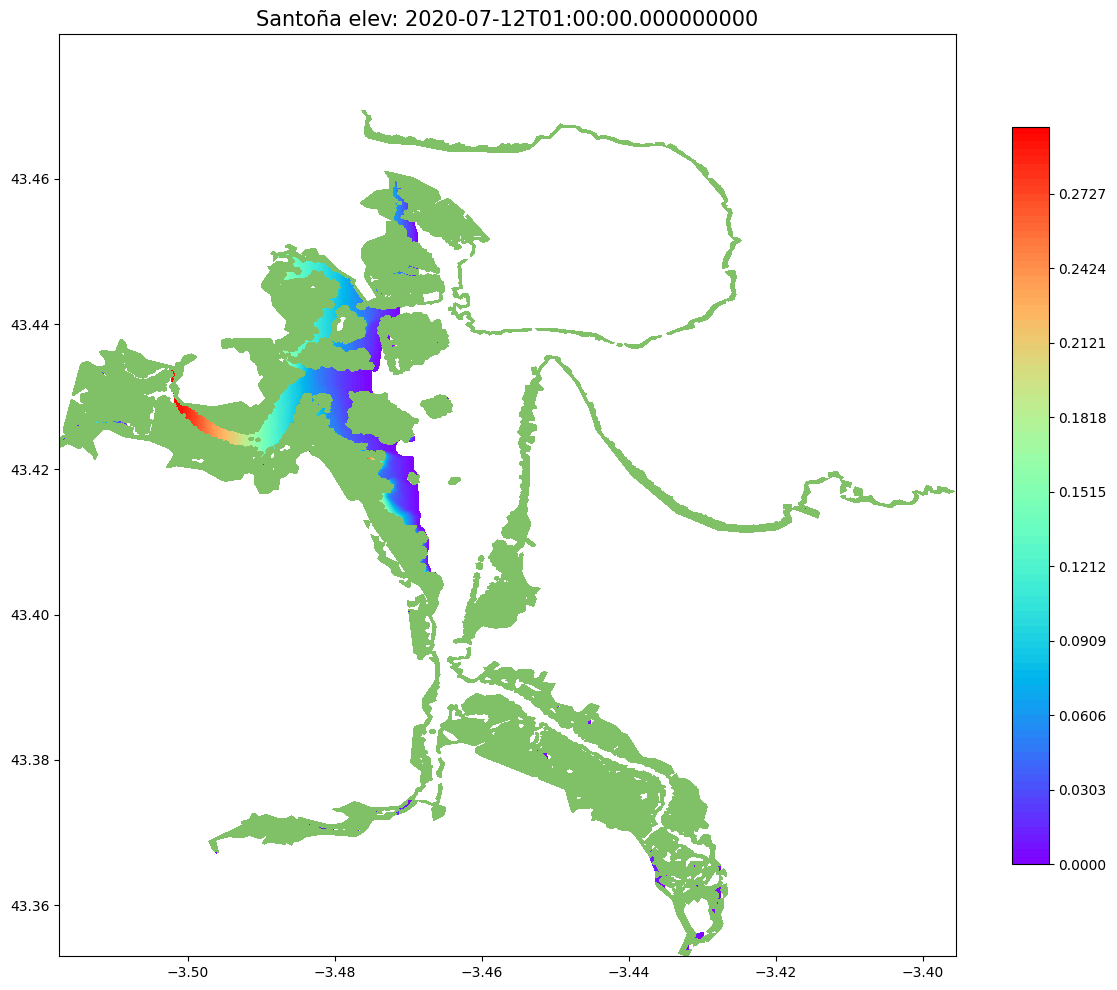

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 10))  # Un solo eje

# Contorno principal (currents)
cax_1 = ax.tricontourf(
    meshtri_1, elev, cmap="rainbow", vmin=0, vmax=0.3, levels=np.linspace(0, 0.3, 100)
)

# Barra de color
plt.colorbar(cax_1, ax=ax, shrink=0.8)

# Imagen de fondo
# ax.imshow(im, origin='upper', extent=[x_left, x_rigth, y_low, y_upper], aspect='equal', alpha=1)

# Contorno para tierra/fondo
ax.tricontourf(meshtri_1, depth_mod, cmap="summer", levels=0, linewidths=0.5)

# Título y ejes
ax.set_title("Santoña elev: " + str(date_schism), fontsize=15)
# ax.set_xlim(x_left, x_rigth)
# ax.set_ylim(y_low, y_upper)

plt.tight_layout()
plt.show()

/tmp/ipykernel_2257219/316621099.py:17: UserWarning: linewidths is ignored by contourf
  ax.tricontourf(meshtri_1, depth_mod, cmap='summer', levels=0, linewidths=0.5)


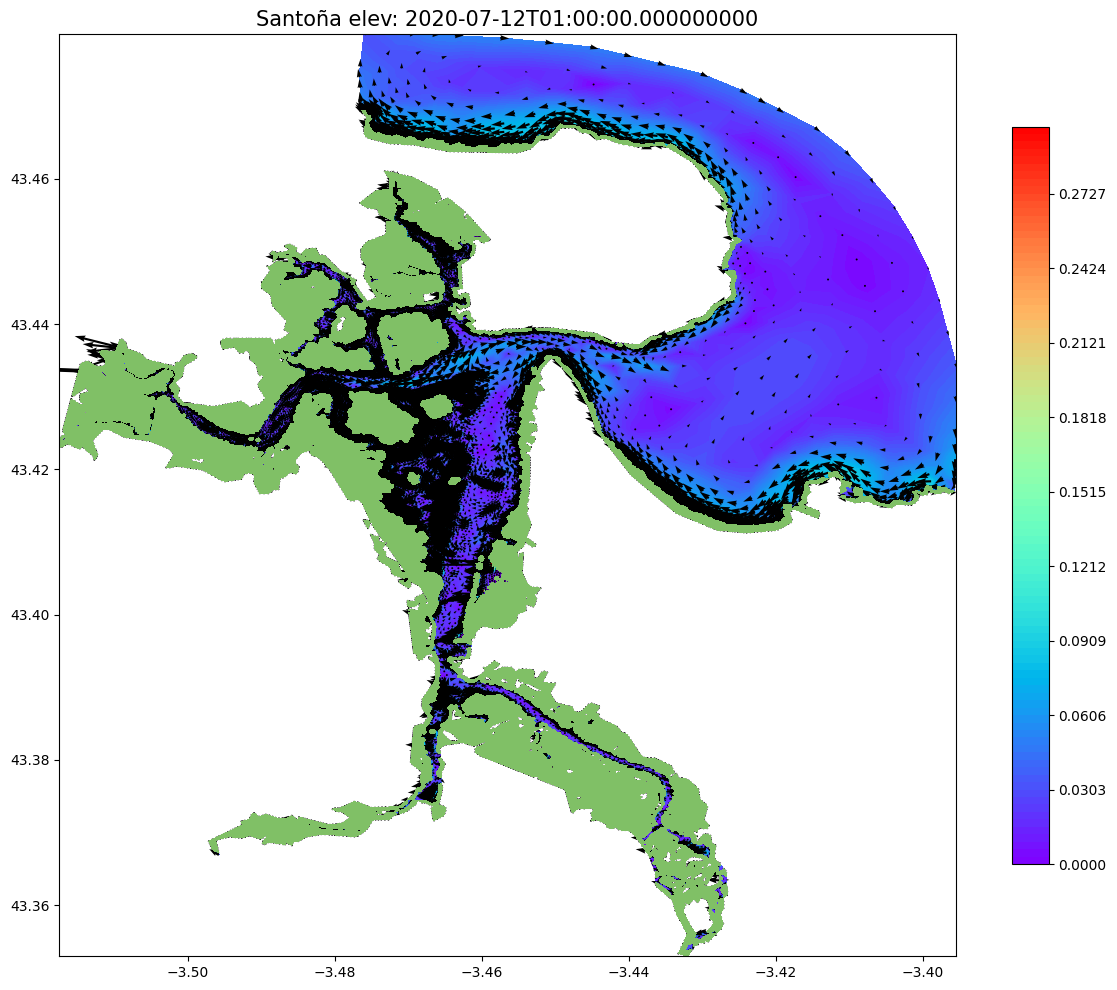

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 10))  # Un solo eje

# Contorno principal (currents)
cax_1 = ax.tricontourf(
    meshtri_1, m, cmap="rainbow", vmin=0, vmax=0.3, levels=np.linspace(0, 0.3, 100)
)
strm = ax.quiver(
    lons,
    lats,
    schout_1.dahv.sel(time=date_schism, two=0),
    schout_1.dahv.sel(time=date_schism, two=1),
    color="k",
    linewidth=20,
    scale=5,
    cmap="autumn",
)  # arrows

# Barra de color
plt.colorbar(cax_1, ax=ax, shrink=0.8)

# Imagen de fondo
# ax.imshow(im, origin='upper', extent=[x_left, x_rigth, y_low, y_upper], aspect='equal', alpha=1)

# Contorno para tierra/fondo
ax.tricontourf(meshtri_1, depth_mod, cmap="summer", levels=0, linewidths=0.5)

# Título y ejes
ax.set_title("Santoña elev: " + str(date_schism), fontsize=15)
# ax.set_xlim(x_left, x_rigth)
# ax.set_ylim(y_low, y_upper)

plt.tight_layout()
plt.show()
